In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [19]:
forced_blocked = 'me2d1.txt'
forced_interleaved = None
free = None

df_main = pd.read_json(forced_blocked, lines=True)
df_main

,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt
0,blocked_practice_epochs_2d1,True,1,1,"[4, 3]",2d1,"[2, 0]",0,2,0.32,False,2769
1,blocked_practice_epochs_2d1,True,2,1,"[1, 4]",2d1,"[2, 0]",2,2,0.60,True,2486
2,blocked_practice_epochs_2d1,True,3,1,"[5, 1]",2d1,"[2, 0]",0,2,1.00,False,2179
3,blocked_practice_epochs_2d1,True,4,1,"[5, 3]",2d1,"[0, 2]",0,0,1.00,True,2695
4,blocked_practice_epochs_2d1,True,5,1,"[3, 3]",2d1,"[0, 2]",2,0,1.00,False,1927
5,blocked_practice_epochs_2d1,True,6,1,"[1, 6]",2d1,"[0, 2]",2,0,1.00,False,2022
6,blocked_practice_epochs_2d1,True,7,1,"[6, 6]",2d1,"[0, 2]",0,0,1.00,True,5667
7,blocked_practice_epochs_2d1,True,8,1,"[5, 6]",2d1,"[0, 2]",0,0,1.00,True,2484
8,blocked_practice_epochs_2d1,True,9,1,"[3, 2]",2d1,"[0, 2]",2,0,1.00,False,2885
9,blocked_practice_epochs_2d1,True,10,1,"[2, 5]",2d1,"[0, 2]",2,0,1.00,False,3062


# Make sure scheduler works

In [16]:
# Count number of practice and test trials
print('Number of trials in each stage')
display(df_main.groupby('stage').count().iloc[:, 1])

# Each feature pair must appear twice during practice and once during test (for each family)
df = df_main.filter(items=['stage', 'famInd', 'features'])
df['featuresStr'] = df.features.astype(str)
df = df.groupby(['stage', 'famInd', 'featuresStr']).count()

print('How many times each feature pair is presented in each family (and each stage)?')
display(df)

print('Are all features presented an equal number of times in each family?')
df = df.groupby(['stage', 'famInd']).nunique().eq(1)
display(df)

del df

Number of trials in each stage


stage
blocked_practice_epochs_2d1    14
Name: trialsComplete, dtype: int64

How many times each feature pair is presented in each family (and each stage)?


features
stage                       famInd featuresStr          
blocked_practice_epochs_2d1 1      [1, 3]              1
                                   [1, 4]              1
                                   [1, 5]              1
                                   [2, 3]              1
                                   [2, 4]              1
                                   [2, 6]              1
                                   [3, 1]              1
                                   [3, 3]              1
                                   [3, 5]              1
                                   [4, 3]              1
                                   [4, 5]              1
                                   [5, 3]              1
                                   [6, 1]              1
                                   [6, 3]              1

Are all features presented an equal number of times in each family?


,,features
stage,famInd,
blocked_practice_epochs_2d1,1,True


# Make sure rules are correctly implemented

Whenever the participant's response is the same as the true correct response, the trial is scored as correct: True
Plot below shows true correct response category for each family at each stage:


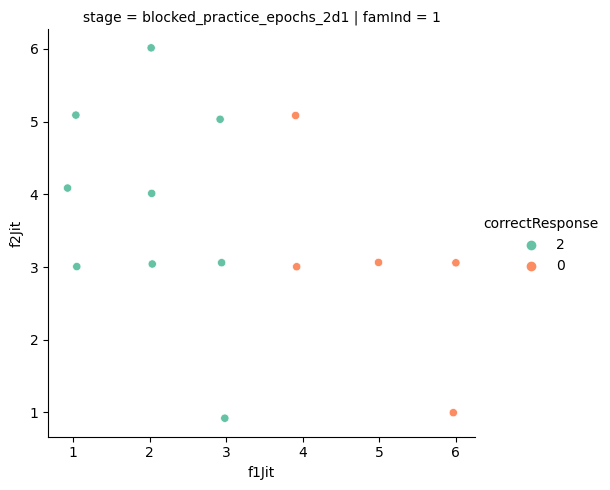

In [17]:
# Check that feedback is given correctly
df = df_main.filter(items=['correctResponse', 'guess', 'correct'])
df['same'] = df.correctResponse == df.guess
print(f'Whenever the participant\'s response is the same as the true correct response, the trial is scored as correct: {np.all(df.same == df.correct)}')

# Check that the feature pairs map onto a their categories consistently
df = df_main.filter(items=['stage', 'famInd', 'features', 'correctResponse'])
df = df.join(df.features.apply(pd.Series).rename(columns={0: 'f1', 1: 'f2'})).drop(columns=['features'])
df['correctResponse'] = df.correctResponse.astype(str)
df['f1Jit'] = df.f1 + np.random.uniform(low=-.1, high=.1, size=df.shape[0])
df['f2Jit'] = df.f2 + np.random.uniform(low=-.1, high=.1, size=df.shape[0])
print('Plot below shows true correct response category for each family at each stage:')
with sns.color_palette("Set2"):
    sns.relplot(data=df, x='f1Jit', y='f2Jit', row='stage', col='famInd', hue='correctResponse')

del df


# Make sure response order is roughly equal

In [5]:
# Check that response items appear on each side roughly equally often
df = df_main.filter(items=['stage', 'famInd', 'responseOrder', 'trialsComplete'])
df['responseOrderStr'] = df.responseOrder.astype(str)
display(df.groupby(['stage', 'famInd', 'responseOrderStr']).count())

del df

responseOrder  trialsComplete
stage       famInd responseOrderStr                               
free_epochs 1      [0, 1]                       91              91
                   [1, 0]                       83              83
            3      [4, 5]                        9               9
                   [5, 4]                       11              11
            4      [6, 7]                       14              14
                   [7, 6]                        8               8
test1       1      [0, 1]                       14              14
                   [1, 0]                       22              22
            3      [4, 5]                       11              11
                   [5, 4]                       25              25
            4      [6, 7]                       16              16
                   [7, 6]                       20              20

# Does confidence grow over time?

<AxesSubplot:xlabel='trialsComplete', ylabel='correct'>

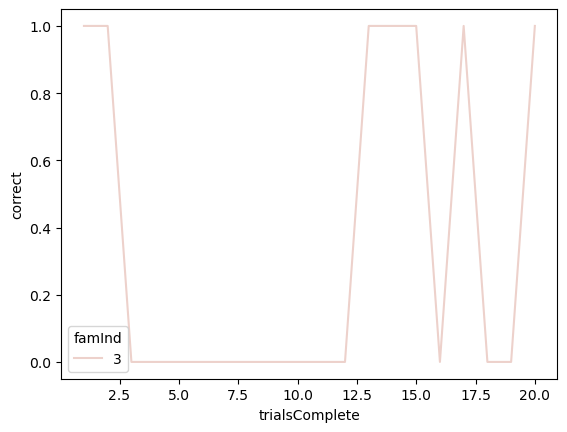

In [11]:
df = df_main.filter(items=['stage', 'trialsComplete', 'famInd', 'correct'])
# df = df[df.stage.eq('free_epochs')]
df.head()
sns.lineplot(x='trialsComplete', y='correct', hue='famInd', data=df)